# Exercício 1

In [2]:
import numpy as np

# Inputs

x = np.array([0.5, -0.2])
y = 1.0

W1 = np.array([[0.3, -0.1],
               [0.2, 0.4]])
b1 = np.array([0.1, -0.2])

W2 = np.array([[0.5, -0.3]])
b2 = np.array([0.2])
n = 0.3

# Hidden layer pre-activation
z1 = W1 @ x + b1   # @ is matrix-vector multiplication
print("z^(1) =", z1)


z^(1) = [ 0.27 -0.18]


In [3]:
a1 = np.tanh(z1)
print("a^(1) =", a1)


a^(1) = [ 0.26362484 -0.17808087]


In [4]:
z2 = W2 @ a1 + b2
print("z2 =", z2)

z2 = [0.38523668]


In [6]:
y_hat = np.tanh(z2)
print("y_hat =", y_hat)

y_hat = [0.36724656]


In [8]:
N = 1
L = (1/N) * (y - y_hat)**2
print("L =", L)


L = [0.40037691]


In [10]:
z1 = W1 @ x + b1
a1 = np.tanh(z1)
z2 = W2 @ a1 + b2
y_hat = np.tanh(z2)

# Backward pass: dL/dy_hat and dL/dz2
N = 1
dL_dyhat = (2/N) * (y_hat - y)
d_tanh = 1.0 - np.tanh(z2)**2
dL_dz2 = dL_dyhat * d_tanh

print(dL_dyhat)
print(d_tanh)
print(dL_dz2)

[-1.26550687]
[0.86512996]
[-1.09482791]


In [11]:
# Gradients for output layer
dL_dW2 = dL_dz2 * a1
dL_db2 = dL_dz2

# Propagate to hidden layer
dL_da1 = dL_dz2 * W2
d_tanh1 = 1.0 - np.tanh(z1)**2
dL_dz1 = dL_da1 * d_tanh1

# Gradients for hidden layer
dL_dW1 = np.outer(dL_dz1, x)
dL_db1 = dL_dz1

print("Gradients for output layer:")
print(" dL/dW2 =", dL_dW2)
print(" dL/db2 =", dL_db2)

print("\nPropagated to hidden layer:")
print(" dL/da1 =", dL_da1)
print(" dL/dz1 =", dL_dz1)

print("\nGradients for hidden layer:")
print(" dL/dW1 =\n", dL_dW1)
print(" dL/db1 =", dL_db1)







Gradients for output layer:
 dL/dW2 = [-0.28862383  0.19496791]
 dL/db2 = [-1.09482791]

Propagated to hidden layer:
 dL/da1 = [[-0.54741396  0.32844837]]
 dL/dz1 = [[-0.50936975  0.31803236]]

Gradients for hidden layer:
 dL/dW1 =
 [[-0.25468488  0.10187395]
 [ 0.15901618 -0.06360647]]
 dL/db1 = [[-0.50936975  0.31803236]]


In [12]:
# Given values
x = np.array([0.5, -0.2])
y = 1.0
W1 = np.array([[0.3, -0.1],
               [0.2, 0.4]])
b1 = np.array([0.1, -0.2])
W2 = np.array([0.5, -0.3])
b2 = 0.2
eta = 0.1  # learning rate

# Forward pass
z1 = W1 @ x + b1
a1 = np.tanh(z1)
z2 = W2 @ a1 + b2
y_hat = np.tanh(z2)

# Backward pass
N = 1
dL_dyhat = (2/N) * (y_hat - y)
d_tanh2 = 1.0 - np.tanh(z2)**2
dL_dz2 = dL_dyhat * d_tanh2

# Gradients for output layer
dL_dW2 = dL_dz2 * a1
dL_db2 = dL_dz2

# Propagate to hidden layer
dL_da1 = dL_dz2 * W2
d_tanh1 = 1.0 - np.tanh(z1)**2
dL_dz1 = dL_da1 * d_tanh1

# Gradients for hidden layer
dL_dW1 = np.outer(dL_dz1, x)
dL_db1 = dL_dz1

# Parameter update
W2_new = W2 - eta * dL_dW2
b2_new = b2 - eta * dL_db2
W1_new = W1 - eta * dL_dW1
b1_new = b1 - eta * dL_db1

print("Updated parameters:")
print("W2 =", W2_new)
print("b2 =", b2_new)
print("W1 =\n", W1_new)
print("b1 =", b1_new)


Updated parameters:
W2 = [ 0.52886238 -0.31949679]
b2 = 0.30948279147136
W1 =
 [[ 0.32546849 -0.1101874 ]
 [ 0.18409838  0.40636065]]
b1 = [ 0.15093698 -0.23180324]


# Exercicio 2

Shapes: (1000, 2) (1000,)
Class counts: {np.int64(0): 500, np.int64(1): 500}


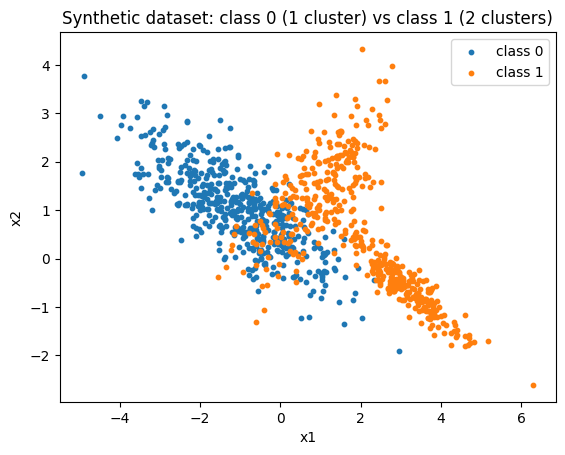

In [14]:
from sklearn.datasets import make_classification
from sklearn.utils import shuffle
import matplotlib.pyplot as plt

# Specs
N = 1000
n0 = N // 2  # class 0 samples
n1 = N - n0  # class 1 samples

# Class 0: 1 cluster
X0, _ = make_classification(
    n_samples=n0,
    n_features=2,
    n_informative=2,
    n_redundant=0,
    n_classes=1,                 # only one class in this subset
    n_clusters_per_class=1,      # 1 cluster
    flip_y=0.0,
    random_state=42
)
y0 = np.zeros(n0, dtype=int)

# Class 1: 2 clusters
X1, _ = make_classification(
    n_samples=n1,
    n_features=2,
    n_informative=2,
    n_redundant=0,
    n_classes=1,                 # only one class in this subset
    n_clusters_per_class=2,      # 2 clusters
    flip_y=0.0,
    random_state=43
)
y1 = np.ones(n1, dtype=int)

# Optional separation tweak: translate class 1 to make boundary challenging but separable
X1 = X1 + np.array([2.0, 0.5])

# Combine and shuffle
X = np.vstack([X0, X1])
y = np.concatenate([y0, y1])
X, y = shuffle(X, y, random_state=42)

# Quick check / visualization
print("Shapes:", X.shape, y.shape)
print("Class counts:", {c: int((y == c).sum()) for c in np.unique(y)})

plt.figure()
plt.scatter(X[y==0,0], X[y==0,1], s=10, label="class 0")
plt.scatter(X[y==1,0], X[y==1,1], s=10, label="class 1")
plt.legend()
plt.title("Synthetic dataset: class 0 (1 cluster) vs class 1 (2 clusters)")
plt.xlabel("x1")
plt.ylabel("x2")
plt.show()

In [15]:
from sklearn.metrics import accuracy_score, confusion_matrix

split = int(0.8 * N)
X_train, y_train = X[:split], y[:split]
X_test, y_test = X[split:], y[split:]

# =========================
# MLP (1 hidden layer, 2 neurons, tanh; BCE loss)
# =========================

def tanh(x):
    return np.tanh(x)

def tanh_deriv(a):
    # assumes a = tanh(z)
    return 1.0 - a**2

def bce_loss_from_probs(p, y_true):
    eps = 1e-12
    p = np.clip(p, eps, 1 - eps)
    return -np.mean(y_true * np.log(p) + (1 - y_true) * np.log(1 - p))

def forward(X, params):
    W1, b1, W2, b2 = params["W1"], params["b1"], params["W2"], params["b2"]
    z1 = X @ W1.T + b1            # (m, 2)
    a1 = tanh(z1)                  # (m, 2)
    z2 = a1 @ W2 + b2              # (m,)
    a2 = tanh(z2)                  # (m,)
    p = (a2 + 1.0) / 2.0           # map tanh -> [0,1]
    cache = {"X": X, "z1": z1, "a1": a1, "z2": z2, "a2": a2, "p": p}
    return p, cache

def backward(y_true, params, cache):
    # Gradients for BCE with p = (tanh(z2)+1)/2
    # dL/dp = (p - y) / (p*(1-p)) averaged over batch
    eps = 1e-12
    p = np.clip(cache["p"], eps, 1 - eps)
    a1, a2, X = cache["a1"], cache["a2"], cache["X"]
    m = X.shape[0]

    dL_dp = (p - y_true) / (p * (1 - p)) / m       # (m,)
    dp_da2 = 0.5
    dL_da2 = dL_dp * dp_da2                         # (m,)
    da2_dz2 = tanh_deriv(a2)
    dL_dz2 = dL_da2 * da2_dz2                       # (m,)

    # Output layer grads
    dW2 = a1.T @ dL_dz2                             # (2,)
    db2 = np.sum(dL_dz2)                            # scalar

    # Backprop to hidden
    dL_da1 = dL_dz2[:, None] * params["W2"][None, :]    # (m,2)
    dL_dz1 = dL_da1 * tanh_deriv(a1)                    # (m,2)
    dW1 = dL_dz1.T @ X                                  # (2,2)
    db1 = np.sum(dL_dz1, axis=0)                        # (2,)

    grads = {"dW1": dW1, "db1": db1, "dW2": dW2, "db2": db2}
    return grads

def update(params, grads, lr):
    params["W1"] -= lr * grads["dW1"]
    params["b1"] -= lr * grads["db1"]
    params["W2"] -= lr * grads["dW2"]
    params["b2"] -= lr * grads["db2"]

# Initialize parameters
rng = np.random.default_rng(0)
params = {
    "W1": rng.normal(scale=0.5, size=(2, 2)),
    "b1": np.zeros(2),
    "W2": rng.normal(scale=0.5, size=2),
    "b2": 0.0,
}

# =========================
# Training
# =========================
lr = 0.01
epochs = 300
loss_hist = []

for ep in range(epochs):
    # forward
    p, cache = forward(X_train, params)
    loss = bce_loss_from_probs(p, y_train)
    loss_hist.append(loss)

    # backward
    grads = backward(y_train, params, cache)

    # update
    update(params, grads, lr)

# =========================
# Evaluation
# =========================
p_test, _ = forward(X_test, params)
y_pred = (p_test >= 0.5).astype(int)
acc = accuracy_score(y_test, y_pred)
cm = confusion_matrix(y_test, y_pred)

print("Test accuracy:", acc)
print("Confusion matrix:\n", cm)



Test accuracy: 0.88
Confusion matrix:
 [[83 18]
 [ 6 93]]


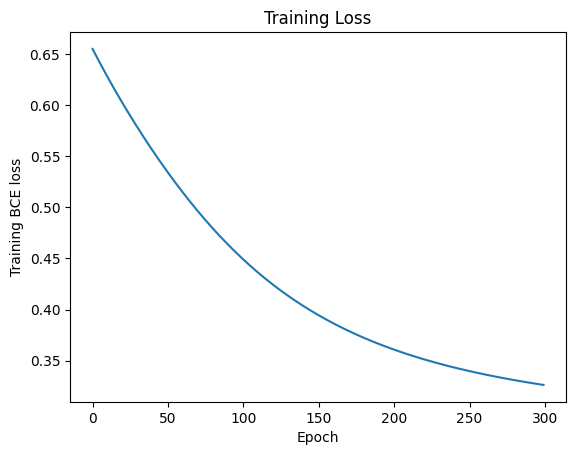

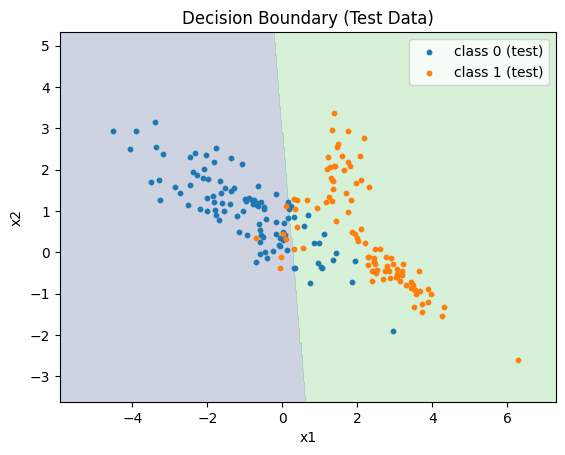

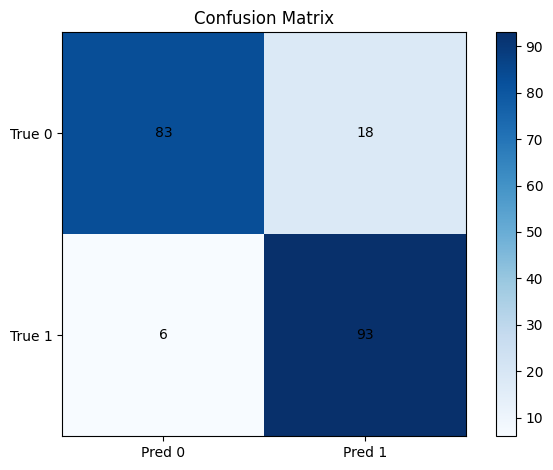

In [16]:
# =========================
# Visualizations
# =========================

# Loss curve
plt.figure()
plt.plot(loss_hist)
plt.xlabel("Epoch")
plt.ylabel("Training BCE loss")
plt.title("Training Loss")

# Decision boundary
def grid_preds(params, xlim, ylim, h=0.02):
    xx, yy = np.meshgrid(
        np.arange(xlim[0], xlim[1], h),
        np.arange(ylim[0], ylim[1], h)
    )
    grid = np.c_[xx.ravel(), yy.ravel()]
    p, _ = forward(grid, params)
    Z = (p >= 0.5).astype(int)
    return xx, yy, Z.reshape(xx.shape)

xlim = (X[:,0].min()-1, X[:,0].max()+1)
ylim = (X[:,1].min()-1, X[:,1].max()+1)
xx, yy, Z = grid_preds(params, xlim, ylim, h=0.03)

plt.figure()
plt.contourf(xx, yy, Z, alpha=0.25, levels=[-0.5,0.5,1.5])
plt.scatter(X_test[y_test==0,0], X_test[y_test==0,1], s=10, label="class 0 (test)")
plt.scatter(X_test[y_test==1,0], X_test[y_test==1,1], s=10, label="class 1 (test)")
plt.title("Decision Boundary (Test Data)")
plt.legend()
plt.xlabel("x1")
plt.ylabel("x2")

# Confusion matrix heatmap (simple text)
plt.figure()
plt.imshow(cm, cmap="Blues")
plt.title("Confusion Matrix")
plt.colorbar()
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, cm[i, j], ha="center", va="center")
plt.xticks([0,1], ["Pred 0", "Pred 1"])
plt.yticks([0,1], ["True 0", "True 1"])

plt.tight_layout()
plt.show()


# Excercise 3

In [27]:
import numpy as np
from sklearn.datasets import make_classification
from sklearn.utils import shuffle
from sklearn.metrics import accuracy_score, confusion_matrix
import matplotlib.pyplot as plt

# =========================
# 1) Generate dataset
# =========================
np.random.seed(42)
N = 1500
n_per_class = [500, 500, 500]  # 3 classes

# Class 0: 2 clusters
X0, _ = make_classification(
    n_samples=n_per_class[0],
    n_features=4,
    n_informative=4,
    n_redundant=0,
    n_classes=1,
    n_clusters_per_class=2,
    class_sep=1.2,
    flip_y=0.0,
    random_state=42
)
y0 = np.zeros(n_per_class[0], dtype=int)
X0 = X0 + np.array([0.0, 0.0, 0.0, 0.0])

# Class 1: 3 clusters
X1, _ = make_classification(
    n_samples=n_per_class[1],
    n_features=4,
    n_informative=4,
    n_redundant=0,
    n_classes=1,
    n_clusters_per_class=3,
    class_sep=1.0,
    flip_y=0.0,
    random_state=43
)
y1 = np.ones(n_per_class[1], dtype=int)
X1 = X1 + np.array([3.0, -1.0, 0.5, 0.0])

# Class 2: 4 clusters
X2, _ = make_classification(
    n_samples=n_per_class[2],
    n_features=4,
    n_informative=4,
    n_redundant=0,
    n_classes=1,
    n_clusters_per_class=4,
    class_sep=1.0,
    flip_y=0.0,
    random_state=44
)
y2 = np.full(n_per_class[2], 2, dtype=int)
X2 = X2 + np.array([-2.0, 2.0, -0.5, 0.5])

X = np.vstack([X0, X1, X2])
y = np.concatenate([y0, y1, y2])
X, y = shuffle(X, y, random_state=42)

# =========================
# 2) Train / test split
# =========================
split = int(0.8 * N)
X_train, y_train = X[:split], y[:split]
X_test, y_test = X[split:], y[split:]

# =========================
# 3) Reusable MLP (same structure as Exercise 2, adjusted for K=3, softmax + CE)
# =========================
def tanh(x):
    return np.tanh(x)

def tanh_deriv(a):
    return 1.0 - a**2  # assumes a = tanh(z)

def softmax(z):
    z = z - np.max(z, axis=1, keepdims=True)
    ez = np.exp(z)
    return ez / np.sum(ez, axis=1, keepdims=True)

def ce_loss_from_probs(P, Y_onehot):
    eps = 1e-12
    P = np.clip(P, eps, 1 - eps)
    return -np.mean(np.sum(Y_onehot * np.log(P), axis=1))

def one_hot(y, K):
    out = np.zeros((y.size, K))
    out[np.arange(y.size), y] = 1.0
    return out

def forward(X, params):
    W1, b1, W2, b2 = params["W1"], params["b1"], params["W2"], params["b2"]
    z1 = X @ W1.T + b1           # (m, H)
    a1 = tanh(z1)                # (m, H)
    z2 = a1 @ W2 + b2            # (m, K)
    P  = softmax(z2)             # (m, K)
    cache = {"X": X, "z1": z1, "a1": a1, "z2": z2, "P": P}
    return P, cache

def backward(Y_onehot, params, cache):
    X, a1, P = cache["X"], cache["a1"], cache["P"]
    W2 = params["W2"]
    m = X.shape[0]

    dZ2 = (P - Y_onehot) / m         # (m, K)  softmax+CE
    dW2 = a1.T @ dZ2                 # (H, K)
    db2 = np.sum(dZ2, axis=0)        # (K,)

    dA1 = dZ2 @ W2.T                 # (m, H)
    dZ1 = dA1 * tanh_deriv(a1)       # (m, H)
    dW1 = dZ1.T @ X                  # (H, D)
    db1 = np.sum(dZ1, axis=0)        # (H,)

    return {"dW1": dW1, "db1": db1, "dW2": dW2, "db2": db2}

def update(params, grads, lr):
    params["W1"] -= lr * grads["dW1"]
    params["b1"] -= lr * grads["db1"]
    params["W2"] -= lr * grads["dW2"]
    params["b2"] -= lr * grads["db2"]

# Architecture / hyperparams (reusing structure: 1 hidden layer with tanh)
D = X_train.shape[1]
H = 8
K = 3
rng = np.random.default_rng(0)
params = {
    "W1": rng.normal(scale=0.3, size=(H, D)),
    "b1": np.zeros(H),
    "W2": rng.normal(scale=0.3, size=(H, K)),
    "b2": np.zeros(K),
}

lr = 0.01
epochs = 350
loss_hist = []

Ytr = one_hot(y_train, K)

# =========================
# 4) Training
# =========================
for ep in range(epochs):
    P, cache = forward(X_train, params)
    loss = ce_loss_from_probs(P, Ytr)
    loss_hist.append(loss)
    grads = backward(Ytr, params, cache)
    update(params, grads, lr)

# =========================
# 5) Evaluation
# =========================
P_test, _ = forward(X_test, params)
y_pred = np.argmax(P_test, axis=1)
acc = accuracy_score(y_test, y_pred)
cm = confusion_matrix(y_test, y_pred)

print("Test accuracy:", acc)
print("Confusion matrix:\n", cm)

Test accuracy: 0.9
Confusion matrix:
 [[ 72   5  13]
 [  1  94   0]
 [ 11   0 104]]


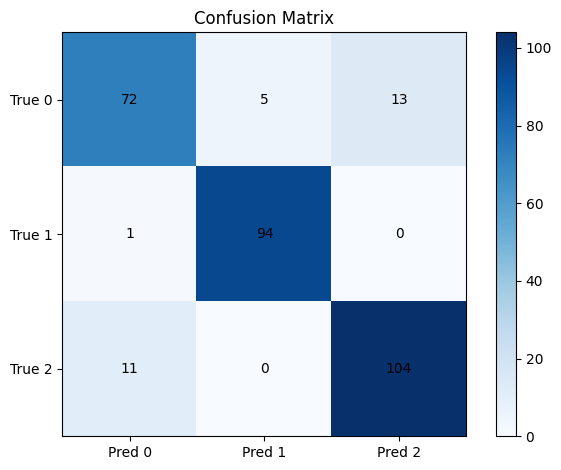

In [31]:
plt.figure()
plt.imshow(cm, cmap="Blues")
plt.title("Confusion Matrix")
plt.colorbar()

# Annotate cells with values
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, cm[i, j], ha="center", va="center", color="black")

plt.xticks([0,1,2], ["Pred 0", "Pred 1", "Pred 2"])
plt.yticks([0,1,2], ["True 0", "True 1", "True 2"])

plt.tight_layout()
plt.show()

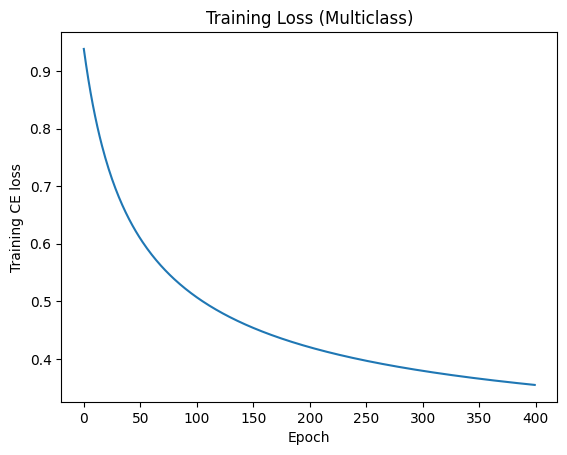

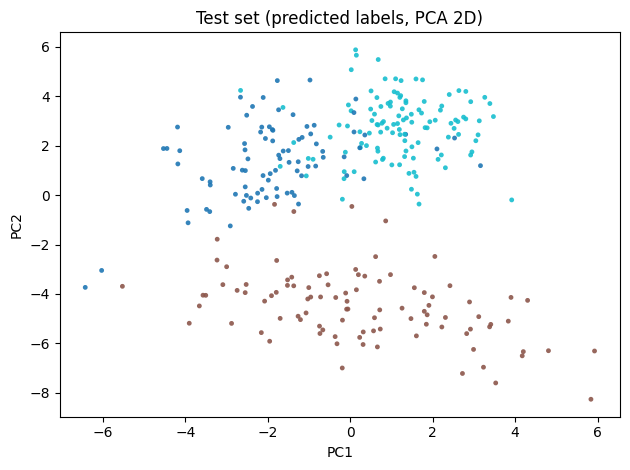

In [36]:
# =========================
# 6) Visualizations
# =========================

# Loss curve
plt.figure()
plt.plot(loss_hist)
plt.xlabel("Epoch")
plt.ylabel("Training CE loss")
plt.title("Training Loss (Multiclass)")

# Simple PCA to 2D for visualization
def pca_2d(X):
    Xc = X - X.mean(axis=0)
    C = np.cov(Xc, rowvar=False)
    eigvals, eigvecs = np.linalg.eigh(C)
    W = eigvecs[:, -2:]  # top-2
    return Xc @ W

X_test_2d = pca_2d(X_test)

plt.figure()
plt.scatter(X_test_2d[:,0], X_test_2d[:,1], c=y_pred, s=12, cmap="tab10", alpha=0.9, edgecolors="none")
plt.title("Test set (predicted labels, PCA 2D)")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.tight_layout()
plt.show()


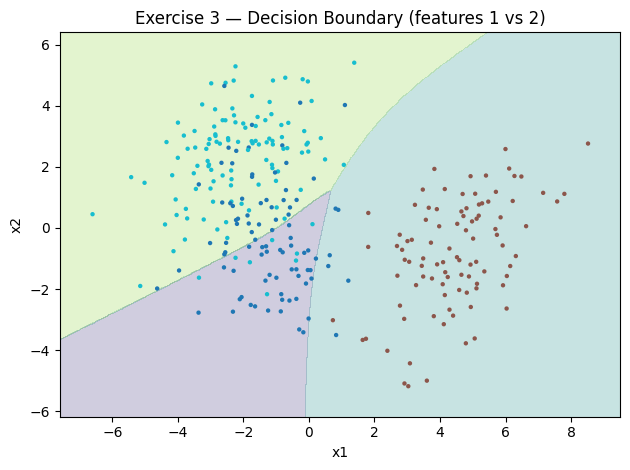

In [26]:
import numpy as np
import matplotlib.pyplot as plt

def decision_boundary_2d(params, forward_fn, X_ref, y_ref=None, feat_idx=(0, 1), h=0.03, title="Decision Boundary"):
    D = X_ref.shape[1]
    f1, f2 = feat_idx

    xlim = (X_ref[:, f1].min() - 1.0, X_ref[:, f1].max() + 1.0)
    ylim = (X_ref[:, f2].min() - 1.0, X_ref[:, f2].max() + 1.0)

    xx, yy = np.meshgrid(
        np.arange(xlim[0], xlim[1], h),
        np.arange(ylim[0], ylim[1], h)
    )
    grid_2d = np.c_[xx.ravel(), yy.ravel()]

    # Fill other features with means from reference set
    means = X_ref.mean(axis=0)
    grid_full = np.tile(means, (grid_2d.shape[0], 1))
    grid_full[:, f1] = grid_2d[:, 0]
    grid_full[:, f2] = grid_2d[:, 1]

    P, _ = forward_fn(grid_full, params)
    if P.ndim == 1:  # binary case with scalar prob
        Z = (P >= 0.5).astype(int)
    else:            # multiclass case with softmax probs
        Z = np.argmax(P, axis=1)

    Z = Z.reshape(xx.shape)

    plt.figure()
    plt.contourf(xx, yy, Z, alpha=0.25, levels=np.arange(Z.max()+2)-0.5)
    if y_ref is not None:
        # plot test/reference points colored by true labels
        plt.scatter(X_ref[:, f1], X_ref[:, f2], c=y_ref, s=10, cmap="tab10", edgecolors="none")
    plt.title(title)
    plt.xlabel(f"x{f1+1}")
    plt.ylabel(f"x{f2+1}")
    plt.tight_layout()
    plt.show()

decision_boundary_2d(
    params=params,
    forward_fn=forward,
    X_ref=X_test,
    y_ref=y_test,
    feat_idx=(0, 1),
    h=0.03,
    title="Exercise 3 — Decision Boundary (features 1 vs 2)"
)

# Excercise 4

In [1]:
import numpy as np
from sklearn.datasets import make_classification
from sklearn.utils import shuffle
from sklearn.metrics import accuracy_score, confusion_matrix
import matplotlib.pyplot as plt

# =========================
# 1) Generate dataset (3 classes, varying clusters: 2, 3, 4)
# =========================
np.random.seed(42)
N = 1800
n_per_class = [600, 600, 600]  # 3 classes

# Class 0: 2 clusters
X0, _ = make_classification(
    n_samples=n_per_class[0],
    n_features=4,
    n_informative=4,
    n_redundant=0,
    n_classes=1,
    n_clusters_per_class=2,
    class_sep=1.2,
    flip_y=0.0,
    random_state=42
)
y0 = np.zeros(n_per_class[0], dtype=int)
X0 = X0 + np.array([0.0, 0.0, 0.0, 0.0])

# Class 1: 3 clusters
X1, _ = make_classification(
    n_samples=n_per_class[1],
    n_features=4,
    n_informative=4,
    n_redundant=0,
    n_classes=1,
    n_clusters_per_class=3,
    class_sep=1.0,
    flip_y=0.0,
    random_state=42
)
y1 = np.ones(n_per_class[1], dtype=int)
X1 = X1 + np.array([3.0, -1.0, 0.5, 0.0])

# Class 2: 4 clusters
X2, _ = make_classification(
    n_samples=n_per_class[2],
    n_features=4,
    n_informative=4,
    n_redundant=0,
    n_classes=1,
    n_clusters_per_class=4,
    class_sep=1.0,
    flip_y=0.0,
    random_state=44
)
y2 = np.full(n_per_class[2], 2, dtype=int)
X2 = X2 + np.array([-2.0, 2.0, -0.5, 0.5])

X = np.vstack([X0, X1, X2])
y = np.concatenate([y0, y1, y2])
X, y = shuffle(X, y, random_state=42)

# =========================
# 2) Train / test split (80/20)
# =========================
split = int(0.8 * N)
X_train, y_train = X[:split], y[:split]
X_test, y_test = X[split:], y[split:]

# =========================
# 3) Deeper MLP (2 hidden layers, tanh; softmax + CE)
# =========================
def tanh(x):
    return np.tanh(x)

def tanh_deriv(a):
    return 1.0 - a**2  # assumes a = tanh(z)

def softmax(z):
    z = z - np.max(z, axis=1, keepdims=True)
    ez = np.exp(z)
    return ez / np.sum(ez, axis=1, keepdims=True)

def ce_loss_from_probs(P, Y_onehot):
    eps = 1e-12
    P = np.clip(P, eps, 1 - eps)
    return -np.mean(np.sum(Y_onehot * np.log(P), axis=1))

def one_hot(y, K):
    out = np.zeros((y.size, K))
    out[np.arange(y.size), y] = 1.0
    return out

def forward(X, params):
    W1, b1 = params["W1"], params["b1"]  # (H1,D), (H1,)
    W2, b2 = params["W2"], params["b2"]  # (H2,H1), (H2,)
    W3, b3 = params["W3"], params["b3"]  # (K,H2), (K,)

    z1 = X @ W1.T + b1               # (m,H1)
    a1 = tanh(z1)                    # (m,H1)
    z2 = a1 @ W2.T + b2              # (m,H2)
    a2 = tanh(z2)                    # (m,H2)
    z3 = a2 @ W3.T + b3              # (m,K)
    P  = softmax(z3)                 # (m,K)

    cache = {"X": X, "z1": z1, "a1": a1, "z2": z2, "a2": a2, "z3": z3, "P": P}
    return P, cache

def backward(Y_onehot, params, cache):
    X, a1, a2, P = cache["X"], cache["a1"], cache["a2"], cache["P"]
    W2, W3 = params["W2"], params["W3"]
    m = X.shape[0]

    # Output layer: softmax + CE
    dZ3 = (P - Y_onehot) / m          # (m,K)
    dW3 = dZ3.T @ a2                  # (K,H2)
    db3 = np.sum(dZ3, axis=0)         # (K,)

    # Hidden layer 2
    dA2 = dZ3 @ W3                    # (m,H2)
    dZ2 = dA2 * tanh_deriv(a2)        # (m,H2)
    dW2 = dZ2.T @ a1                  # (H2,H1)
    db2 = np.sum(dZ2, axis=0)         # (H2,)

    # Hidden layer 1
    dA1 = dZ2 @ W2                    # (m,H1)
    dZ1 = dA1 * tanh_deriv(a1)        # (m,H1)
    dW1 = dZ1.T @ X                   # (H1,D)
    db1 = np.sum(dZ1, axis=0)         # (H1,)

    return {"dW1": dW1, "db1": db1, "dW2": dW2, "db2": db2, "dW3": dW3, "db3": db3}

def update(params, grads, lr):
    params["W1"] -= lr * grads["dW1"]
    params["b1"] -= lr * grads["db1"]
    params["W2"] -= lr * grads["dW2"]
    params["b2"] -= lr * grads["db2"]
    params["W3"] -= lr * grads["dW3"]
    params["b3"] -= lr * grads["db3"]

# Architecture / hyperparams
D = X_train.shape[1]
K = 3
H1 = 16
H2 = 12
rng = np.random.default_rng(0)
params = {
    "W1": rng.normal(scale=0.3, size=(H1, D)),
    "b1": np.zeros(H1),
    "W2": rng.normal(scale=0.3, size=(H2, H1)),
    "b2": np.zeros(H2),
    "W3": rng.normal(scale=0.3, size=(K, H2)),
    "b3": np.zeros(K),
}

lr = 0.01
epochs = 400
loss_hist = []
Ytr = one_hot(y_train, K)

# =========================
# 4) Training
# =========================
for ep in range(epochs):
    P, cache = forward(X_train, params)
    loss = ce_loss_from_probs(P, Ytr)
    loss_hist.append(loss)
    grads = backward(Ytr, params, cache)
    update(params, grads, lr)

# =========================
# 5) Evaluation
# =========================
P_test, _ = forward(X_test, params)
y_pred = np.argmax(P_test, axis=1)
acc = accuracy_score(y_test, y_pred)
cm = confusion_matrix(y_test, y_pred)

print("Test accuracy:", acc)
print("Confusion matrix:\n", cm)

Test accuracy: 0.8833333333333333
Confusion matrix:
 [[ 89   4  13]
 [  3 117   0]
 [ 21   1 112]]


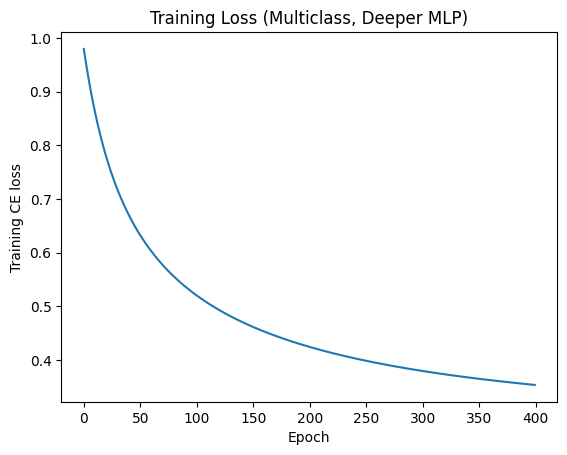

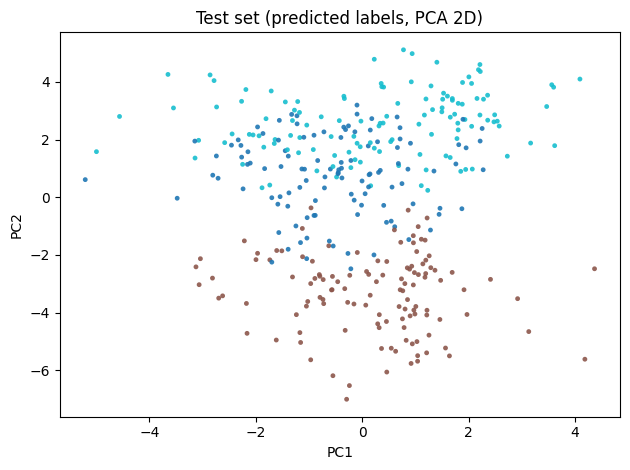

In [2]:
# =========================
# 6) Visualizations
# =========================
# Loss curve
plt.figure()
plt.plot(loss_hist)
plt.xlabel("Epoch")
plt.ylabel("Training CE loss")
plt.title("Training Loss (Multiclass, Deeper MLP)")

# PCA to 2D for visualization of predicted labels
def pca_2d(X):
    Xc = X - X.mean(axis=0)
    C = np.cov(Xc, rowvar=False)
    eigvals, eigvecs = np.linalg.eigh(C)
    W = eigvecs[:, -2:]  # top-2 eigenvectors
    return Xc @ W

X_test_2d = pca_2d(X_test)

plt.figure()
plt.scatter(X_test_2d[:,0], X_test_2d[:,1], c=y_pred, s=12, cmap="tab10", alpha=0.9, edgecolors="none")
plt.title("Test set (predicted labels, PCA 2D)")
plt.xlabel("PC1")
plt.ylabel("PC2")

plt.tight_layout()
plt.show()


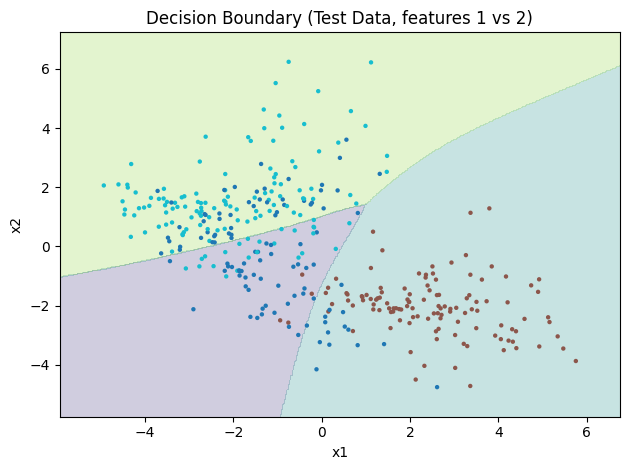

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

def decision_boundary_2d(params, forward_fn, X_ref, y_ref=None, feat_idx=(0, 1), h=0.03, title="Decision Boundary"):
    D = X_ref.shape[1]
    f1, f2 = feat_idx

    xlim = (X_ref[:, f1].min() - 1.0, X_ref[:, f1].max() + 1.0)
    ylim = (X_ref[:, f2].min() - 1.0, X_ref[:, f2].max() + 1.0)

    xx, yy = np.meshgrid(
        np.arange(xlim[0], xlim[1], h),
        np.arange(ylim[0], ylim[1], h)
    )
    grid_2d = np.c_[xx.ravel(), yy.ravel()]

    # Fill other features with means from reference set
    means = X_ref.mean(axis=0)
    grid_full = np.tile(means, (grid_2d.shape[0], 1))
    grid_full[:, f1] = grid_2d[:, 0]
    grid_full[:, f2] = grid_2d[:, 1]

    P, _ = forward_fn(grid_full, params)
    if P.ndim == 1:  # binary case with scalar prob
        Z = (P >= 0.5).astype(int)
    else:            # multiclass case with softmax probs
        Z = np.argmax(P, axis=1)

    Z = Z.reshape(xx.shape)

    plt.figure()
    plt.contourf(xx, yy, Z, alpha=0.25, levels=np.arange(Z.max()+2)-0.5)
    if y_ref is not None:
        # plot test/reference points colored by true labels
        plt.scatter(X_ref[:, f1], X_ref[:, f2], c=y_ref, s=10, cmap="tab10", edgecolors="none")
    plt.title(title)
    plt.xlabel(f"x{f1+1}")
    plt.ylabel(f"x{f2+1}")
    plt.tight_layout()
    plt.show()

decision_boundary_2d(params, forward, X_test, y_test, feat_idx=(0, 1), h=0.03, title="Decision Boundary (Test Data, features 1 vs 2)")

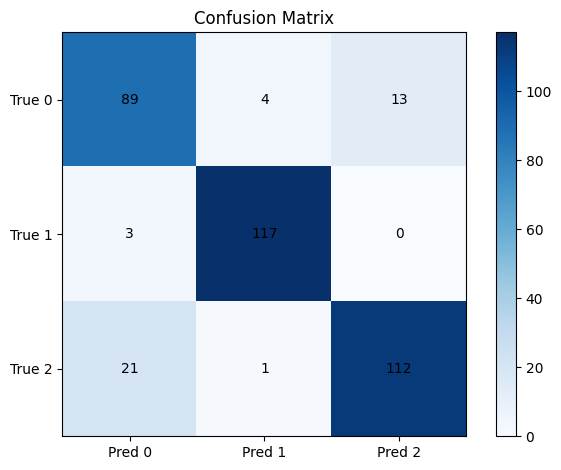

In [4]:
plt.figure()
plt.imshow(cm, cmap="Blues")
plt.title("Confusion Matrix")
plt.colorbar()

# Annotate cells with values
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, cm[i, j], ha="center", va="center", color="black")

plt.xticks([0,1,2], ["Pred 0", "Pred 1", "Pred 2"])
plt.yticks([0,1,2], ["True 0", "True 1", "True 2"])

plt.tight_layout()
plt.show()